In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

BASE = '/content/drive/MyDrive/ecommerce-analytics'

# Load clean sales data
df = pd.read_csv(f'{BASE}/data/processed/stage2_sales_clean.csv',
                 parse_dates=['InvoiceDate'])

# Set clean chart style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi']      = 120
plt.rcParams['font.size']       = 11
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False

print(f"Loaded: {len(df):,} rows")
print(f"Date range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")

Mounted at /content/drive
Loaded: 1,007,913 rows
Date range: 2009-12-01 to 2011-12-09


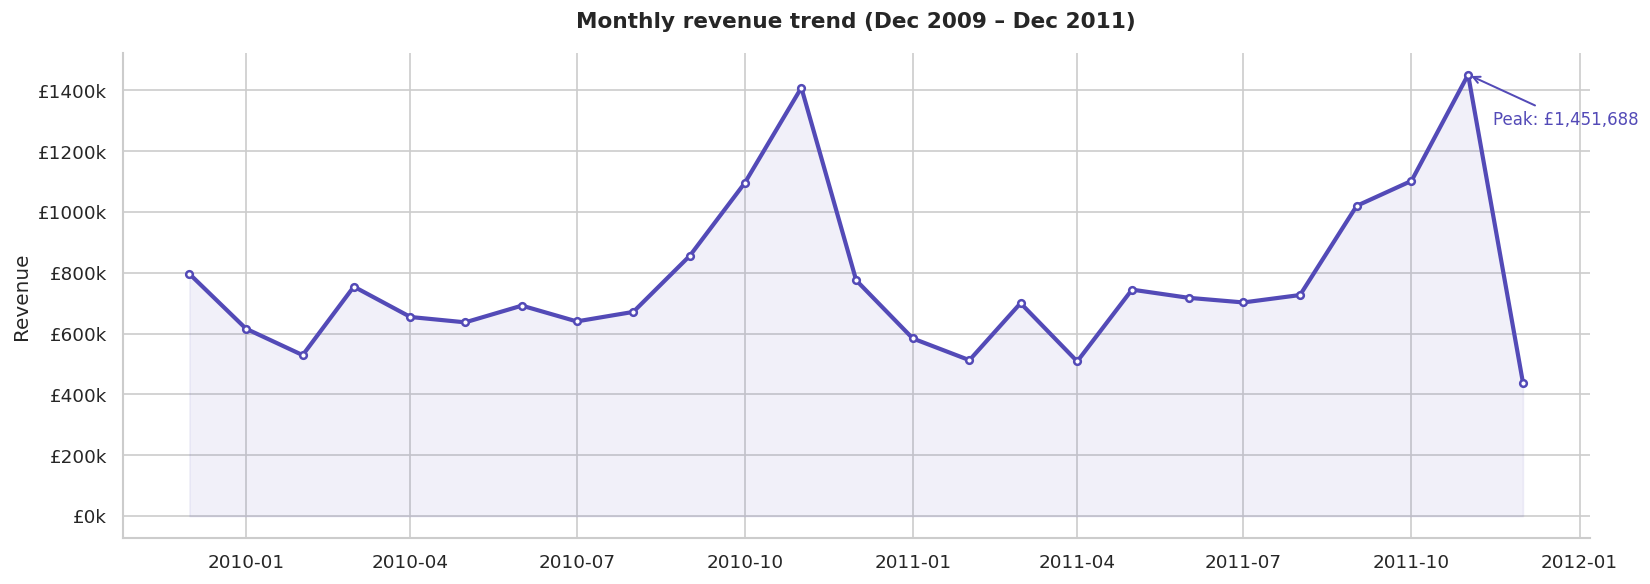

Chart 1 saved.


In [ ]:
monthly = (df.groupby(['Year', 'Month'])['TotalRevenue']
             .sum()
             .reset_index())
monthly['period'] = pd.to_datetime(
    monthly[['Year','Month']].assign(day=1))

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(monthly['period'], monthly['TotalRevenue'],
        color='#534AB7', linewidth=2.5, marker='o',
        markersize=4, markerfacecolor='white',
        markeredgewidth=1.5)

ax.fill_between(monthly['period'], monthly['TotalRevenue'],
                alpha=0.08, color='#534AB7')

# Annotate peak month
peak_idx = monthly['TotalRevenue'].idxmax()
peak_row = monthly.loc[peak_idx]
ax.annotate(f"Peak: £{peak_row['TotalRevenue']:,.0f}",
            xy=(peak_row['period'], peak_row['TotalRevenue']),
            xytext=(15, -30), textcoords='offset points',
            fontsize=10, color='#534AB7',
            arrowprops=dict(arrowstyle='->', color='#534AB7',
                           lw=1.2))

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))
ax.set_title('Monthly revenue trend (Dec 2009 – Dec 2011)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Revenue')
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/chart1_monthly_revenue.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved.")

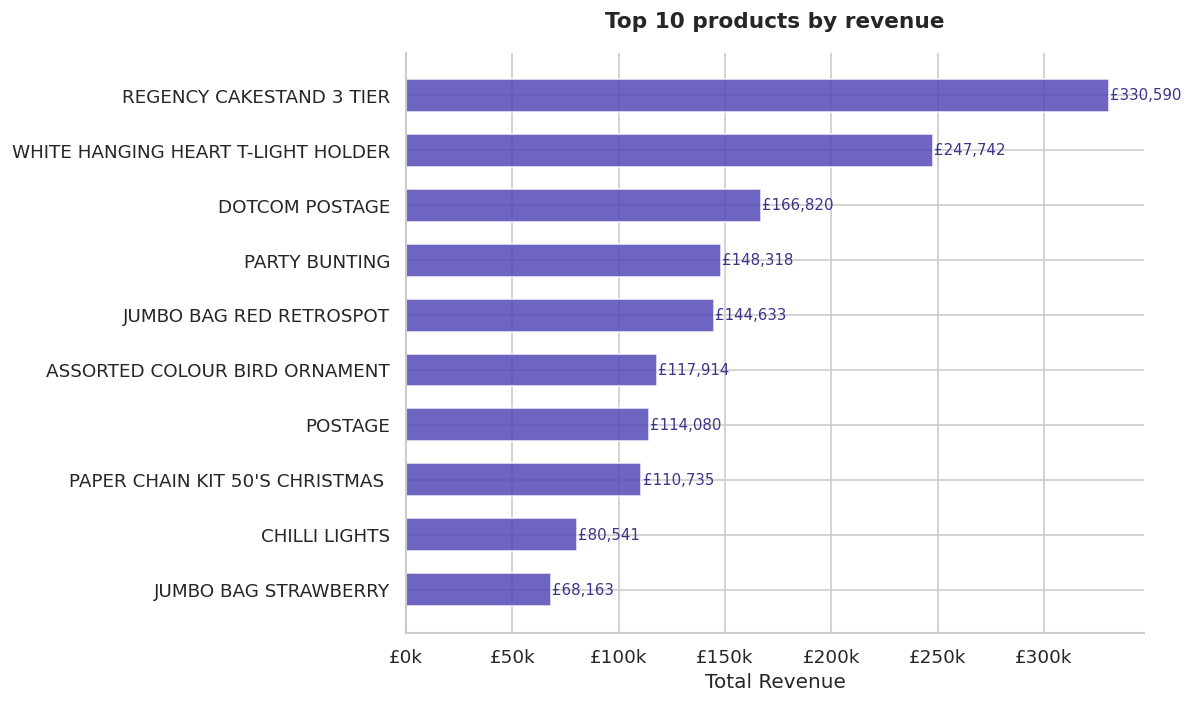

Chart 2 saved.


In [ ]:
top_products = (df.groupby('Description')['TotalRevenue']
                  .sum()
                  .sort_values(ascending=False)
                  .head(10)
                  .reset_index())

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(top_products['Description'],
               top_products['TotalRevenue'],
               color='#534AB7', alpha=0.85, height=0.6)

# Add value labels on each bar
for bar, val in zip(bars, top_products['TotalRevenue']):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'£{val:,.0f}', va='center', fontsize=9,
            color='#3C3489')

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))
ax.invert_yaxis()
ax.set_title('Top 10 products by revenue',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue')
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/chart2_top_products.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved.")

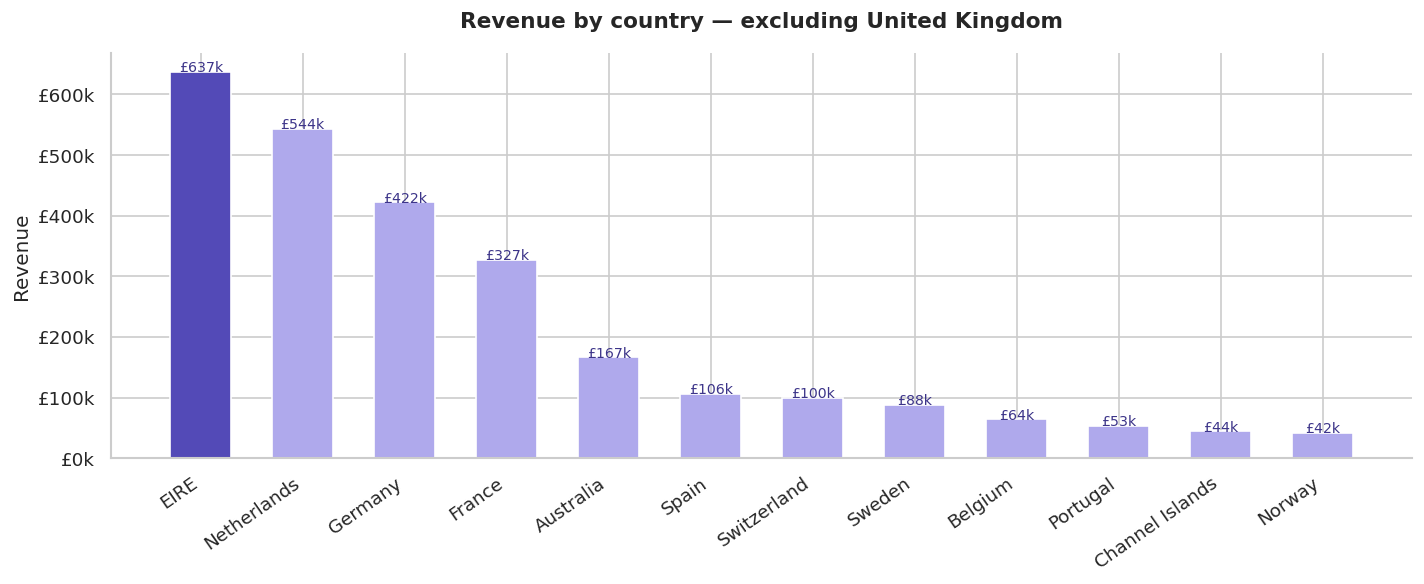

Chart 3 saved.


In [ ]:
country_rev = (df[df['Country'] != 'United Kingdom']
               .groupby('Country')['TotalRevenue']
               .sum()
               .sort_values(ascending=False)
               .head(12)
               .reset_index())

fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#534AB7' if i == 0 else '#AFA9EC'
          for i in range(len(country_rev))]

bars = ax.bar(country_rev['Country'],
              country_rev['TotalRevenue'],
              color=colors, width=0.6)

for bar, val in zip(bars, country_rev['TotalRevenue']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 200,
            f'£{val/1000:.0f}k',
            ha='center', fontsize=8.5, color='#3C3489')

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))
ax.set_title('Revenue by country — excluding United Kingdom',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Revenue')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/chart3_country_revenue.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved.")

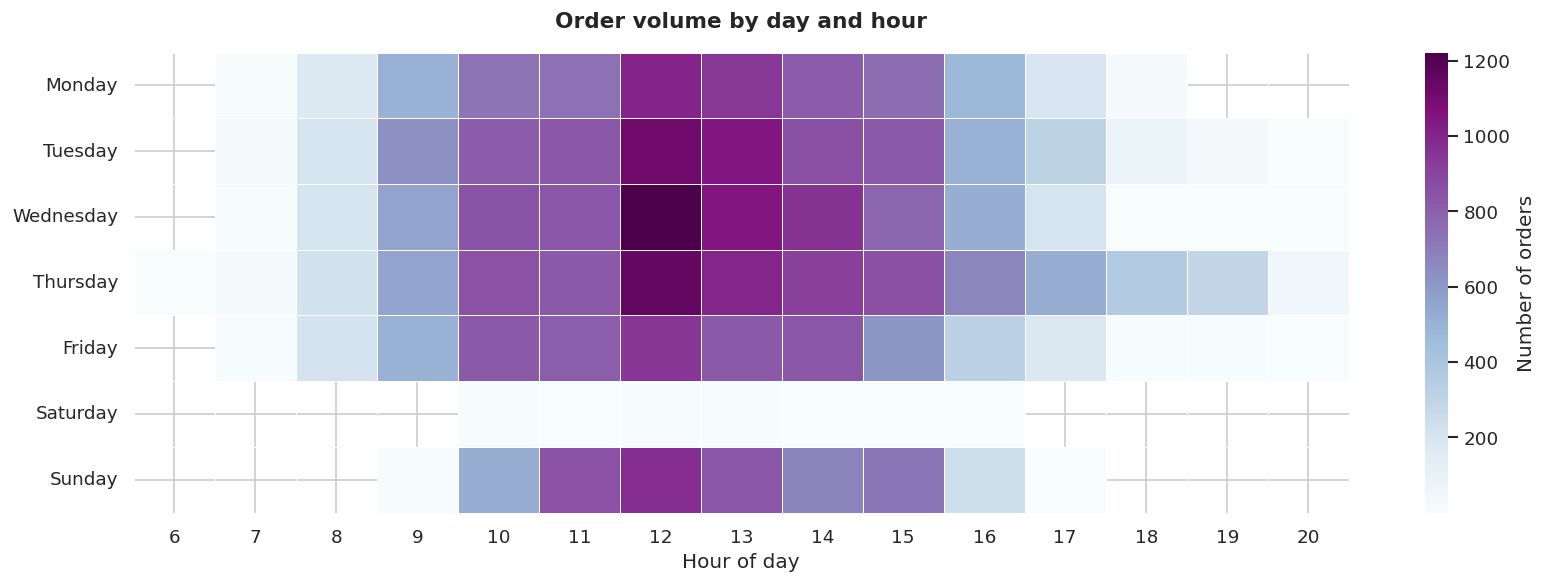

Chart 4 saved.


In [ ]:
day_order = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']

heatmap_data = (df.groupby(['Day','Hour'])['Invoice']
                  .nunique()
                  .reset_index()
                  .rename(columns={'Invoice':'num_orders'}))

heatmap_pivot = (heatmap_data
                 .pivot(index='Day', columns='Hour',
                        values='num_orders')
                 .reindex(day_order))

fig, ax = plt.subplots(figsize=(14, 5))

sns.heatmap(heatmap_pivot,
            cmap='BuPu',
            linewidths=0.3,
            linecolor='white',
            annot=False,
            fmt='.0f',
            cbar_kws={'label': 'Number of orders'},
            ax=ax)

ax.set_title('Order volume by day and hour',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Hour of day')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/chart4_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved.")

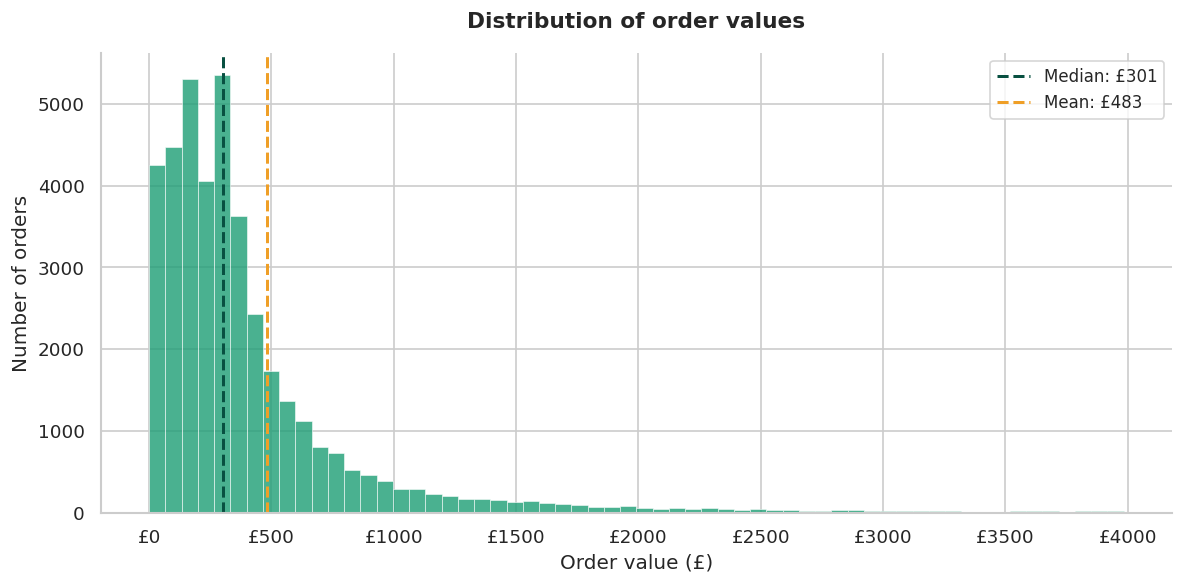

Chart 5 saved.
Median order value: £300.74
Mean order value  : £482.56


In [ ]:
order_values = (df.groupby('Invoice')['TotalRevenue']
                  .sum()
                  .reset_index())

# Cap at 99th percentile for readable chart
cap = order_values['TotalRevenue'].quantile(0.99)
order_values_capped = order_values[
    order_values['TotalRevenue'] <= cap]

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(order_values_capped['TotalRevenue'],
        bins=60, color='#1D9E75', alpha=0.8,
        edgecolor='white', linewidth=0.4)

median_val = order_values['TotalRevenue'].median()
mean_val   = order_values['TotalRevenue'].mean()

ax.axvline(median_val, color='#085041',
           linestyle='--', linewidth=1.8,
           label=f'Median: £{median_val:.0f}')
ax.axvline(mean_val, color='#EF9F27',
           linestyle='--', linewidth=1.8,
           label=f'Mean: £{mean_val:.0f}')

ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:.0f}'))
ax.set_title('Distribution of order values',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Order value (£)')
ax.set_ylabel('Number of orders')
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/chart5_order_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Chart 5 saved.")
print(f"Median order value: £{median_val:.2f}")
print(f"Mean order value  : £{mean_val:.2f}")

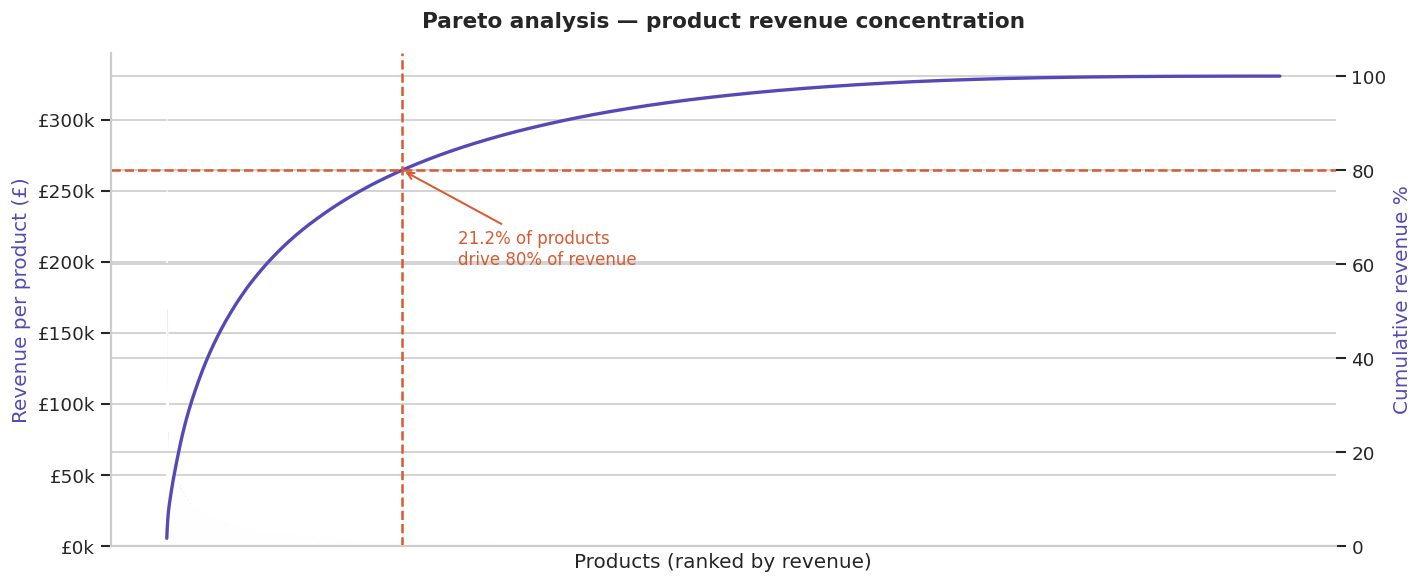

Chart 6 saved.
Products driving 80% of revenue: 1,040 of 4,917
That is 21.2% of all products


In [ ]:
product_rev = (df.groupby('StockCode')['TotalRevenue']
               .sum()
               .sort_values(ascending=False)
               .reset_index())

total = product_rev['TotalRevenue'].sum()
product_rev['cumulative_pct'] = (
    product_rev['TotalRevenue'].cumsum() / total * 100)
product_rev['product_pct'] = (
    np.arange(1, len(product_rev)+1) /
    len(product_rev) * 100)

# Find 80% crossover point
idx_80 = (product_rev['cumulative_pct'] <= 80).sum()
pct_products = product_rev.loc[idx_80, 'product_pct']

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(range(len(product_rev)),
        product_rev['TotalRevenue'],
        color='#AFA9EC', width=1.0, alpha=0.7)
ax1.set_ylabel('Revenue per product (£)', color='#534AB7')
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))

ax2 = ax1.twinx()
ax2.plot(range(len(product_rev)),
         product_rev['cumulative_pct'],
         color='#534AB7', linewidth=2)

ax2.axhline(80, color='#D85A30', linestyle='--',
            linewidth=1.5, label='80% revenue')
ax2.axvline(idx_80, color='#D85A30', linestyle='--',
            linewidth=1.5)
ax2.annotate(f'{pct_products:.1f}% of products\ndrive 80% of revenue',
             xy=(idx_80, 80),
             xytext=(idx_80 + len(product_rev)*0.05, 60),
             fontsize=10, color='#D85A30',
             arrowprops=dict(arrowstyle='->',
                            color='#D85A30', lw=1.2))

ax2.set_ylabel('Cumulative revenue %', color='#534AB7')
ax2.set_ylim(0, 105)
ax1.set_xlabel('Products (ranked by revenue)')
ax1.set_title('Pareto analysis — product revenue concentration',
              fontsize=13, fontweight='bold', pad=15)
ax1.set_xticks([])
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/chart6_pareto.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Chart 6 saved.")
print(f"Products driving 80% of revenue: {idx_80:,} of {len(product_rev):,}")
print(f"That is {pct_products:.1f}% of all products")

In [ ]:
import os

output_dir = f'{BASE}/outputs'
charts = [f for f in os.listdir(output_dir)
          if f.endswith('.png')]

print(f"Charts saved to Drive ({len(charts)} files):")
for c in sorted(charts):
    size = os.path.getsize(f'{output_dir}/{c}') / 1024
    print(f"  {c}  ({size:.0f} KB)")

print("\nStage 4 DONE!")
print("Next: Stage 5 — RFM Customer Segmentation")

Charts saved to Drive (6 files):
  chart1_monthly_revenue.png  (96 KB)
  chart2_top_products.png  (101 KB)
  chart3_country_revenue.png  (102 KB)
  chart4_heatmap.png  (60 KB)
  chart5_order_distribution.png  (49 KB)
  chart6_pareto.png  (89 KB)

Stage 4 DONE!
Next: Stage 5 — RFM Customer Segmentation
